# Phase 1: Dataset Inspection & EDA


In [1]:
!pip install huggingface_hub pandas matplotlib seaborn scikit-learn pypdf tqdm datasets


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import snapshot_download
from pypdf import PdfReader
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

print("Downloading dataset files from Hugging Face...")
dataset_path = snapshot_download(repo_id="BassemRamdan/data", repo_type="dataset")
print(f"Dataset downloaded to: {dataset_path}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2485 files:   0%|          | 0/2485 [00:00<?, ?it/s]

Dataset downloaded to: C:\Users\basse\.cache\huggingface\hub\datasets--BassemRamdan--data\snapshots\2b8c61feeb3d3fbb54fe258d5a19516f110e29f8


In [3]:
def get_file_hash(filepath):
    """Generate MD5 hash for exact duplicate detection of files."""
    hasher = hashlib.md5()
    with open(filepath, 'rb') as afile:
        buf = afile.read()
        hasher.update(buf)
    return hasher.hexdigest()

data = []
categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.git')]

print(f"Found {len(categories)} categories. Processing PDFs...")

for category in tqdm(categories, desc="Categories"):
    cat_path = os.path.join(dataset_path, category)
    for filename in os.listdir(cat_path):
        if filename.lower().endswith('.pdf'):
            file_path = os.path.join(cat_path, filename)

            file_size_kb = os.path.getsize(file_path) / 1024
            file_hash = get_file_hash(file_path)

            text = ""
            num_pages = 0
            is_corrupted = False

            try:
                reader = PdfReader(file_path)
                num_pages = len(reader.pages)
                for page in reader.pages:
                    extracted = page.extract_text()
                    if extracted:
                        text += extracted + " "
            except Exception as e:
                is_corrupted = True

            clean_text = text.strip()

            data.append({
                "category": category,
                "filename": filename,
                "file_size_kb": file_size_kb,
                "num_pages": num_pages,
                "is_corrupted": is_corrupted,
                "file_hash": file_hash,
                "text": clean_text,
                "char_count": len(clean_text),
                "word_count": len(clean_text.split())
            })

df = pd.DataFrame(data)
print(f"\nDataset shape: {df.shape}")
df.head()

Found 24 categories. Processing PDFs...


Categories:   0%|          | 0/24 [00:00<?, ?it/s]


Dataset shape: (2484, 9)


,category,filename,file_size_kb,num_pages,is_corrupted,file_hash,text,char_count,word_count
0,ACCOUNTANT,10554236.pdf,47.146484,5,False,194e7174831e4be4eb0efe9d23de9bec,ACCOUNTANT\nSummary\nFinancial Accountant spec...,24295,3469
1,ACCOUNTANT,10674770.pdf,24.565430,2,False,03838c246b76065b4c1de7bc00ae6bf2,STAFF ACCOUNTANT\nSummary\nHighly analytical a...,7567,1047
2,ACCOUNTANT,11163645.pdf,21.809570,2,False,c03f8839680b6a3733075c0ffed85187,ACCOUNTANT\nProfessional Summary\nTo obtain a ...,4838,628
3,ACCOUNTANT,11759079.pdf,22.234375,2,False,990a195961dae687294467974bc4e543,SENIOR ACCOUNTANT\nExperience\nCompany Name\n ...,5986,849
4,ACCOUNTANT,12065211.pdf,23.744141,2,False,2fd2e1b9333535adf87d4caf36d564a2,SENIOR ACCOUNTANT\nProfessional Summary\nSenio...,5622,783


In [4]:
print("--- PDF Validity Report ---")
corrupted_files = df[df['is_corrupted'] == True]
print(f"Number of corrupted PDFs (cannot be read by PyPDF): {len(corrupted_files)}")

empty_text_files = df[(df['is_corrupted'] == False) & (df['char_count'] == 0)]
print(f"Number of valid PDFs with NO extracted text: {len(empty_text_files)}")
print("*Note: These are likely scanned images requiring OCR in the next phase.")

--- PDF Validity Report ---
Number of corrupted PDFs (cannot be read by PyPDF): 0
Number of valid PDFs with NO extracted text: 1
*Note: These are likely scanned images requiring OCR in the next phase.


In [5]:
print("--- Duplicate Detection ---")
exact_duplicates = df.duplicated(subset=['file_hash'], keep=False)
num_exact_duplicates = exact_duplicates.sum()
print(f"Number of exact duplicate files (identical binary): {num_exact_duplicates}")

if num_exact_duplicates > 0:
    display(df[exact_duplicates].sort_values('file_hash').head(4)[['category', 'filename', 'file_size_kb', 'file_hash']])

valid_text_df = df[df['char_count'] > 50]
text_duplicates = valid_text_df.duplicated(subset=['text'], keep=False)
num_text_duplicates = text_duplicates.sum()
print(f"\nNumber of text-based exact duplicates (different file, identical extracted text): {num_text_duplicates}")

--- Duplicate Detection ---
Number of exact duplicate files (identical binary): 0

Number of text-based exact duplicates (different file, identical extracted text): 4


C:\Users\basse\AppData\Local\Temp\ipykernel_35216\3673253086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette="viridis")


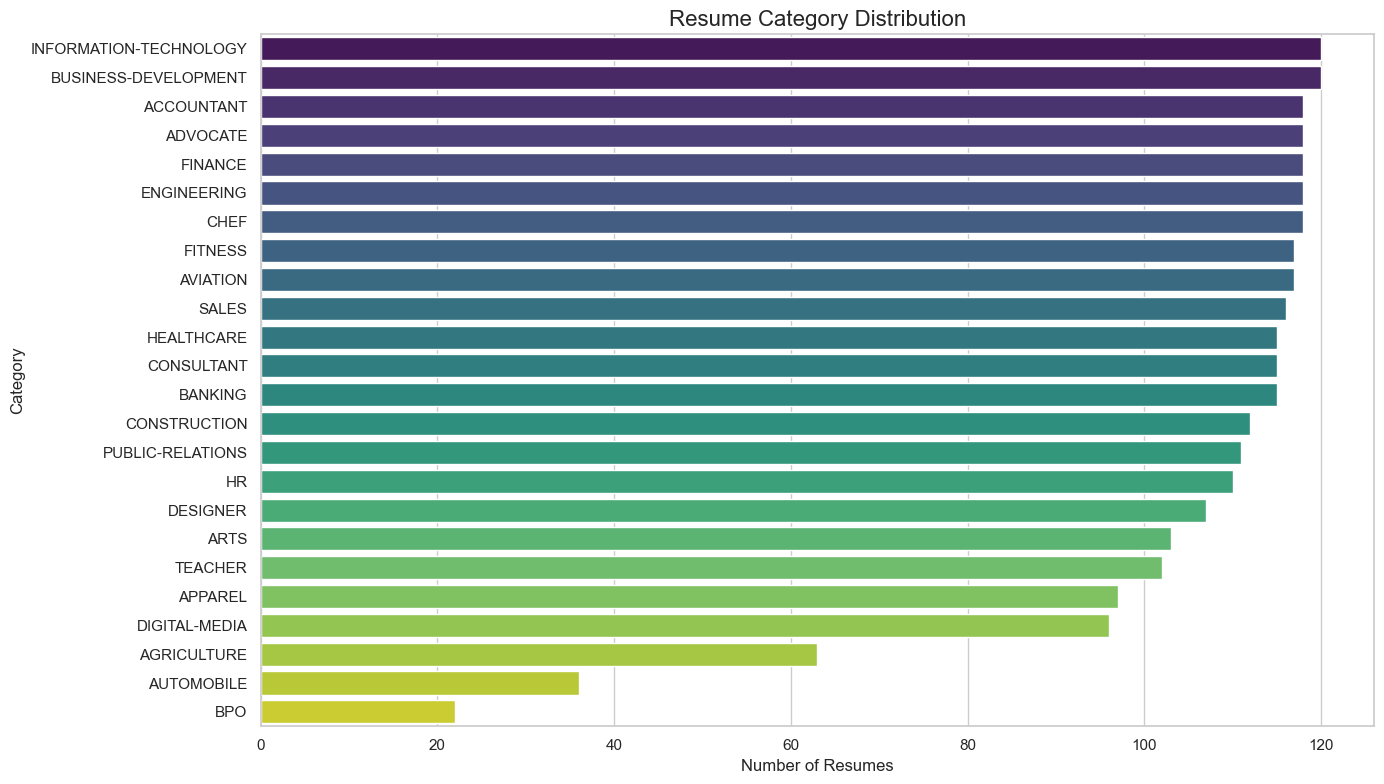

In [6]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette="viridis")
plt.title('Resume Category Distribution', fontsize=16)
plt.xlabel('Number of Resumes', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

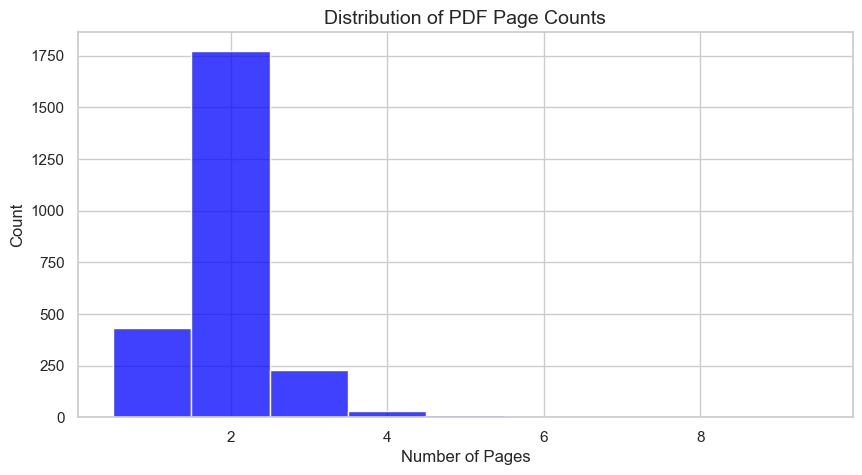

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['num_pages'] > 0]['num_pages'], bins=20, color='blue', discrete=True)
plt.title('Distribution of PDF Page Counts', fontsize=14)
plt.xlabel('Number of Pages', fontsize=12)
plt.show()

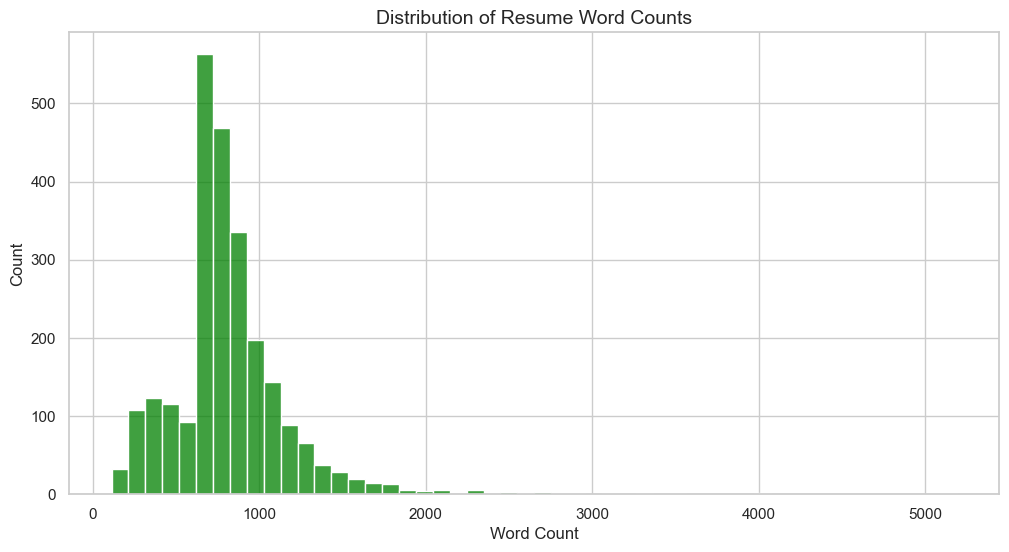

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['word_count'] > 0]['word_count'], bins=50, color='green')
plt.title('Distribution of Resume Word Counts', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.show()

C:\Users\basse\AppData\Local\Temp\ipykernel_35216\2711918778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['word_count'] > 0], x='word_count', y='category', palette="Set2")


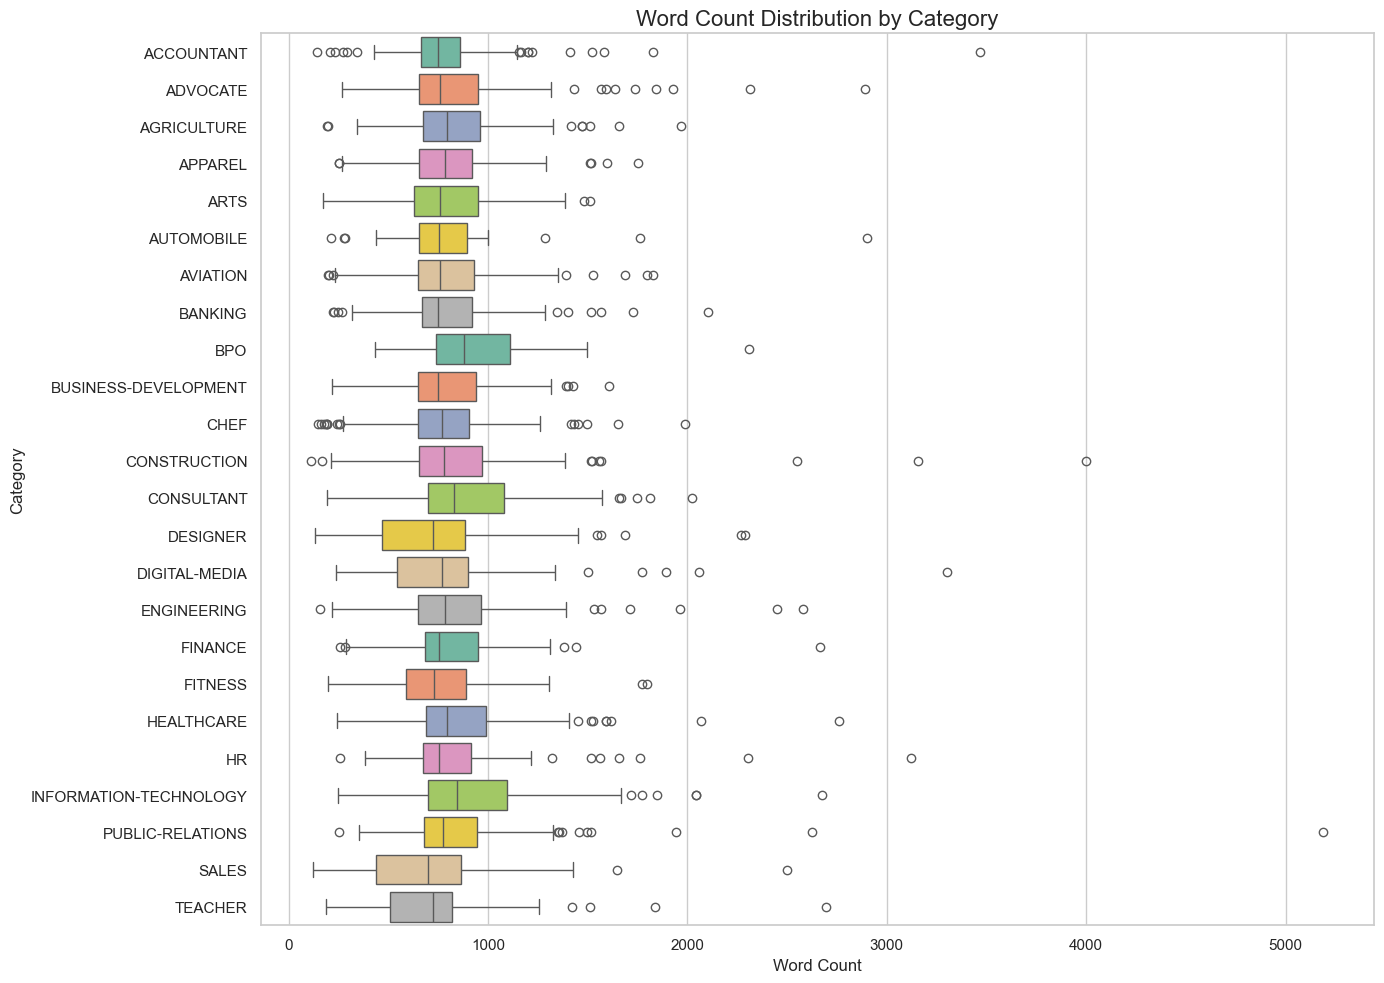

In [9]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=df[df['word_count'] > 0], x='word_count', y='category', palette="Set2")
plt.title('Word Count Distribution by Category', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
print("===== DATASET SUMMARY =====")

print(f"Total PDFs: {len(df)}")
print(f"Categories: {df['category'].nunique()}")

print("\n===== CORRUPTED =====")
print(df["is_corrupted"].value_counts())

print("\n===== DUPLICATES =====")
print(f"Exact duplicate files: {df['file_hash'].duplicated().sum()}")

print("\n===== TEXT EXTRACTION =====")
print(f"No text: {(df['word_count'] == 0).sum()}")
print(f"< 20 words: {(df['word_count'] < 20).sum()}")

print("\n===== PAGES =====")
print(df["num_pages"].value_counts().sort_index())

print("\n===== WORD COUNT =====")
print(df["word_count"].describe())

print("\n===== CATEGORY DISTRIBUTION =====")
print(df["category"].value_counts())

===== DATASET SUMMARY =====
Total PDFs: 2484
Categories: 24

===== CORRUPTED =====
is_corrupted
False    2484
Name: count, dtype: int64

===== DUPLICATES =====
Exact duplicate files: 0

===== TEXT EXTRACTION =====
No text: 1
< 20 words: 1

===== PAGES =====
num_pages
1     433
2    1775
3     229
4      32
5      11
6       2
7       1
9       1
Name: count, dtype: int64

===== WORD COUNT =====
count    2484.000000
mean      812.416667
std       362.176036
min         0.000000
25%       652.000000
50%       760.000000
75%       934.250000
max      5190.000000
Name: word_count, dtype: float64

===== CATEGORY DISTRIBUTION =====
category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ACCOUNTANT                118
ADVOCATE                  118
FINANCE                   118
ENGINEERING               118
CHEF                      118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                1